# U.S. Gross Domestic Product and Employee Wage Growth (2024 – Present)

## Analysis Specification

### Description
This analytical tracking framework explores the interplay between U.S. macroeconomic growth and employee earnings data from 2024 to the present. By combining broad output indexes—such as Real GDP, Potential GDP, and GDP per capita—with dynamic hourly and weekly wage metrics across different demographic groups, this document serves to map out whether current productivity gains are filtering equitably into workers' real earnings. The project relies strictly on continuous, high-frequency time-series datasets provided by the Federal Reserve Economic Data (FRED) system.

---

## Objectives

*   **Evaluate Growth vs. Potential Outputs:** Monitor the official trajectory of economic output using Real GDP (`GDPC1`) mapped against Potential GDP (`GDPPOT`) to ascertain the output gap and identify periods of economic overheating or cooling.
*   **Deconstruct Employee Wage Trajectories:** Analyze differences in nominal, weekly, and hourly earnings metrics across distinct employee demographics to determine if high-skilled labor segments (`LEU0252918500Q`) outpace or lag behind general private workforce averages (`CES0500000011`, `LES1252881500Q`).
*   **Measure Disposable Income Health:** Cross-examine real gross productivity spikes per capita (`A939RX0Q048SBEA`) with the actual movement of Real Disposable Personal Income (`DSPIC96`) to gauge the average individual’s true purchasing power in an inflationary climate.
*   **Establish Automated Pipelines:** Provide a standardized, reproducible technical baseline using structural components like Python frameworks (`pandas-datareader`) to live-fetch and continuously refresh these specific macroeconomic indexes for long-term tracking.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `GDPC1`: Real Gross Domestic Product
  - `GDPPOT`: Real Potential Gross Domestic Product
  - `DSPIC96`: Real Disposable Personal Income
  - `A939RX0Q048SBEA` : Real Gross Domestic Product Per Capita
  - `LES1252881500Q`: Employed full time: Median usual weekly nominal earnings (second quartile): Wage and salary workers: 16 years and over
  - `LEU0252918500Q`: Employed full time: Median usual weekly nominal earnings (second quartile): Wage and salary workers: Bachelor's degree and higher: 25 years and over
  - `CES0500000011`: Average Weekly Earnings of All Employees, Total Private 

---



## Pre-Processing

### Install System Dependencies

In [9]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [10]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [11]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [12]:
start = datetime(2005, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## Earnings for U.S. Employees

### Weekly Earnings (2024 - Present)

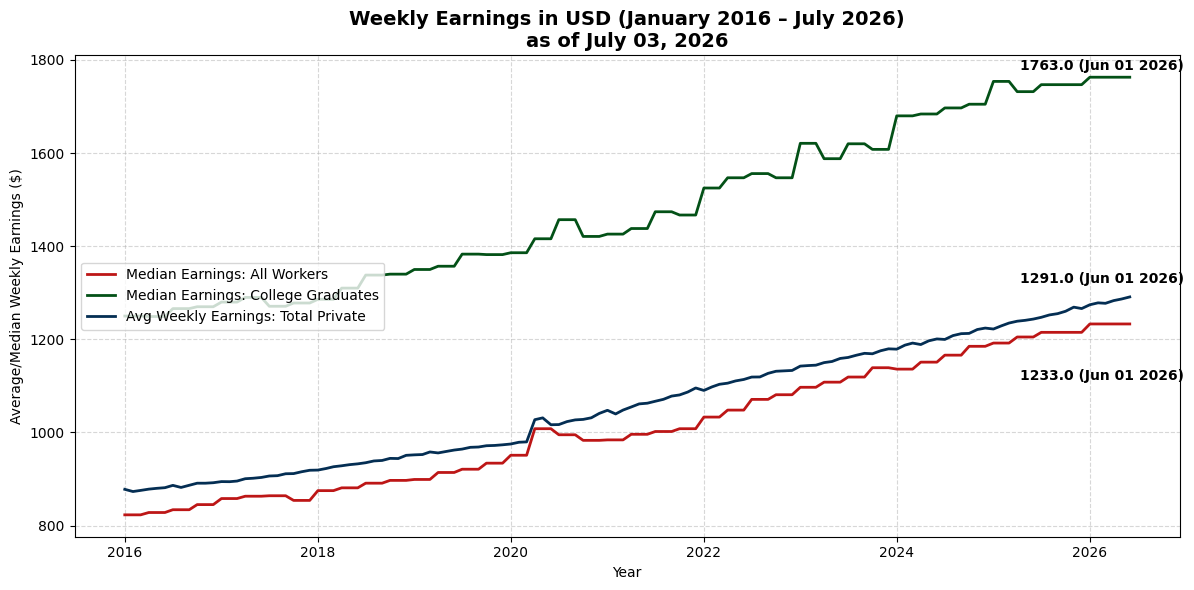

In [17]:
earn_series = {
    'LES1252881500Q': 'Median Earnings: All Workers',
    'LEU0252918500Q': 'Median Earnings: College Graduates',
    'CES0500000011': 'Avg Weekly Earnings: Total Private'
}

df_raw = web.DataReader(list(earn_series.keys()), 'fred', start, end)
df_raw.rename(columns=earn_series, inplace=True)
df_raw = df_raw.ffill()

df_plot = df_raw.loc[start:end]

# values
r1_date = df_raw['Median Earnings: All Workers'].dropna().index[-1]
r1_val = df_raw['Median Earnings: All Workers'].dropna().iloc[-1]


r2_date = df_raw['Avg Weekly Earnings: Total Private'].dropna().index[-1]
r2_val = df_raw['Avg Weekly Earnings: Total Private'].dropna().iloc[-1]

r3_date = df_raw['Median Earnings: College Graduates'].dropna().index[-1]
r3_val = df_raw['Median Earnings: College Graduates'].dropna().iloc[-1]

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['Median Earnings: All Workers'], 
         label='Median Earnings: All Workers', 
         color="#bd1616", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Median Earnings: College Graduates'], 
         label='Median Earnings: College Graduates', 
         color="#035117", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Avg Weekly Earnings: Total Private'], 
         label='Avg Weekly Earnings: Total Private', 
         color="#042E53", 
         linewidth=2)

y = plt.ylim()[1] * 0.9

events = {
    '2024-09-01': 'Q3 2024',
    '2025-03-01': 'Q1 2025',
    '2025-09-01': 'Q3 2025',
    '2026-03-01': 'Q1 2026'
}

plt.title(f'Weekly Earnings in USD ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', 
          fontsize=14, 
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average/Median Weekly Earnings ($)')  # Updated label
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='center left')
plt.tight_layout()
plt.annotate(f"{r1_val:.1f} ({r1_date.strftime('%b %Y')})", 
             (r1_date, r1_val), 
             textcoords = "offset points", 
             xytext = (-20,-40), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{r2_val:.1f} ({r2_date.strftime('%b %Y')})", 
             (r2_date, r2_val), 
             textcoords = "offset points", 
             xytext = (-20,10), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.annotate(f"{r3_val:.1f} ({r3_date.strftime('%b %Y')})", 
             (r3_date, r3_val), 
             textcoords = "offset points", 
             xytext = (-20,5), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')

plt.show()

### Earnings Growth Year-over-Year (2024 - Present)

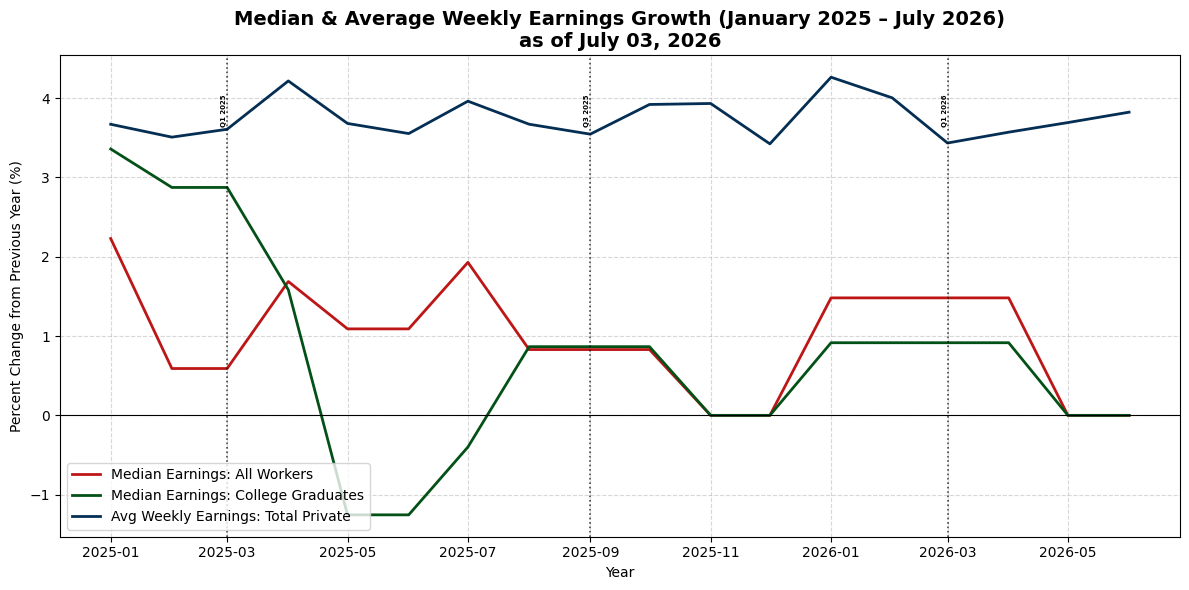

In [14]:
start = datetime(2024, 1, 1)
plot_start = start + relativedelta(years=1)

df_rate = pd.DataFrame(index=df_raw.index)
df_rate['All Workers (YoY %Change)'] = df_raw['Median Earnings: All Workers'].pct_change(4) * 100
df_rate['College Graduates (YoY %Change)'] = df_raw['Median Earnings: College Graduates'].pct_change(4) * 100
df_rate['Total Private Employees (YoY %Change)'] = df_raw['Avg Weekly Earnings: Total Private'].pct_change(12) * 100

df_plot = df_rate.loc[plot_start:end]

plt.figure(figsize=(12, 6))

plt.plot(df_plot.index, df_plot['All Workers (YoY %Change)'], 
         label='Median Earnings: All Workers', 
         color="#bd1616", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['College Graduates (YoY %Change)'], 
         label='Median Earnings: College Graduates', 
         color="#035117", 
         linewidth=2)

plt.plot(df_plot.index, df_plot['Total Private Employees (YoY %Change)'], 
         label='Avg Weekly Earnings: Total Private', 
         color="#042E53", 
         linewidth=2)

y = df_plot.max().max() * 0.95

add_event_lines_small(events, df_plot, y)

plt.title(f'Median & Average Weekly Earnings Growth ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', 
          fontsize=14, 
          fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

plt.show()

## Gross Domestic Product (GDP) in the U.S. (January 2024-Present)
### Real GDP, Gross Potential GDP, Real Disposable Income

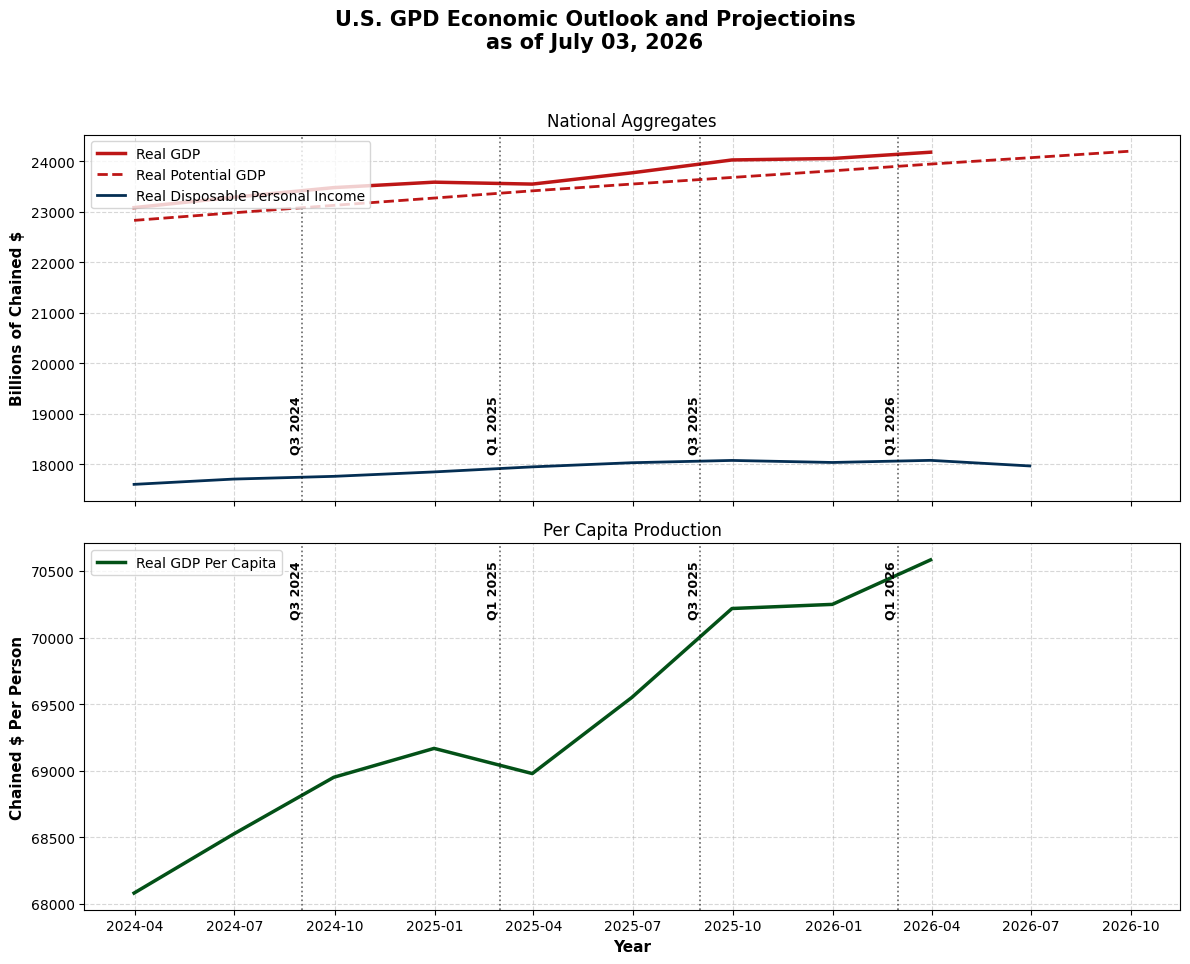

In [15]:
start = datetime(2024, 1, 1)
plot_start = start + relativedelta(years=1)

macro_series = {
    'GDPC1': 'Real GDP',
    'GDPPOT': 'Real Potential GDP',
    'DSPIC96': 'Real Disposable Personal Income',
    'A939RX0Q048SBEA': 'Real GDP Per Capita'
}

df_raw = web.DataReader(list(macro_series.keys()), 'fred', start, end)
df_raw.rename(columns=macro_series, inplace=True)

df_plot = df_raw.resample('QE').mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_plot.index, df_plot['Real GDP'], 
         label='Real GDP', 
         color='#bd1616', 
         linewidth=2.5)

ax1.plot(df_plot.index, df_plot['Real Potential GDP'], 
         label='Real Potential GDP', 
         color='#bd1616', 
         linewidth=2, 
         linestyle='--')

ax1.plot(df_plot.index, df_plot['Real Disposable Personal Income'], 
         label='Real Disposable Personal Income', 
         color='#042E53', 
         linewidth=2)
        
ax1.set_ylabel('Billions of Chained $', fontweight='bold', fontsize=11)
ax1.title.set_text('National Aggregates')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True)

ax2.plot(df_plot.index, df_plot['Real GDP Per Capita'], 
         label='Real GDP Per Capita', color='#035117', linewidth=2.5)

ax2.set_xlabel('Year', fontweight='bold', fontsize=11)
ax2.set_ylabel('Chained $ Per Person', fontweight='bold', fontsize=11)
ax2.title.set_text('Per Capita Production')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True)

y1_text = df_plot[['Real GDP', 'Real Potential GDP', 'Real Disposable Personal Income']].max().max() * 0.8
y2_text = df_plot['Real GDP Per Capita'].max() 

for date_str, label in events.items():
    evt_date = pd.to_datetime(date_str)
    
    if df_plot.index.min() <= evt_date <= df_plot.index.max():
        
        # Draw on Top Subplot (ax1)
        ax1.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax1.text(evt_date, y1_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
        ax2.axvline(x=evt_date, color='black', linestyle=':', linewidth=1.2, alpha=0.6)
        ax2.text(evt_date, y2_text, label,
                 rotation=90, 
                 verticalalignment='top',
                 horizontalalignment='right',
                 fontsize=9,
                 fontweight='bold')
        
plt.suptitle(f'U.S. GPD Economic Outlook and Projectioins\nas of {str_current_date}', 
             fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.93]) 

plt.show()

### GDP, PGDP, DPI Growth (YoY %) (2016 - Present)

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_25897/3532021734.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['Real GDP'] = df_quarterly['Real GDP'].pct_change(4) * 100
/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_25897/3532021734.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['Real Disposable Personal Income'] = df_quarterly['Real Disposable Personal Income'].pct_change(4) * 100
/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_25897/3532021734.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated a

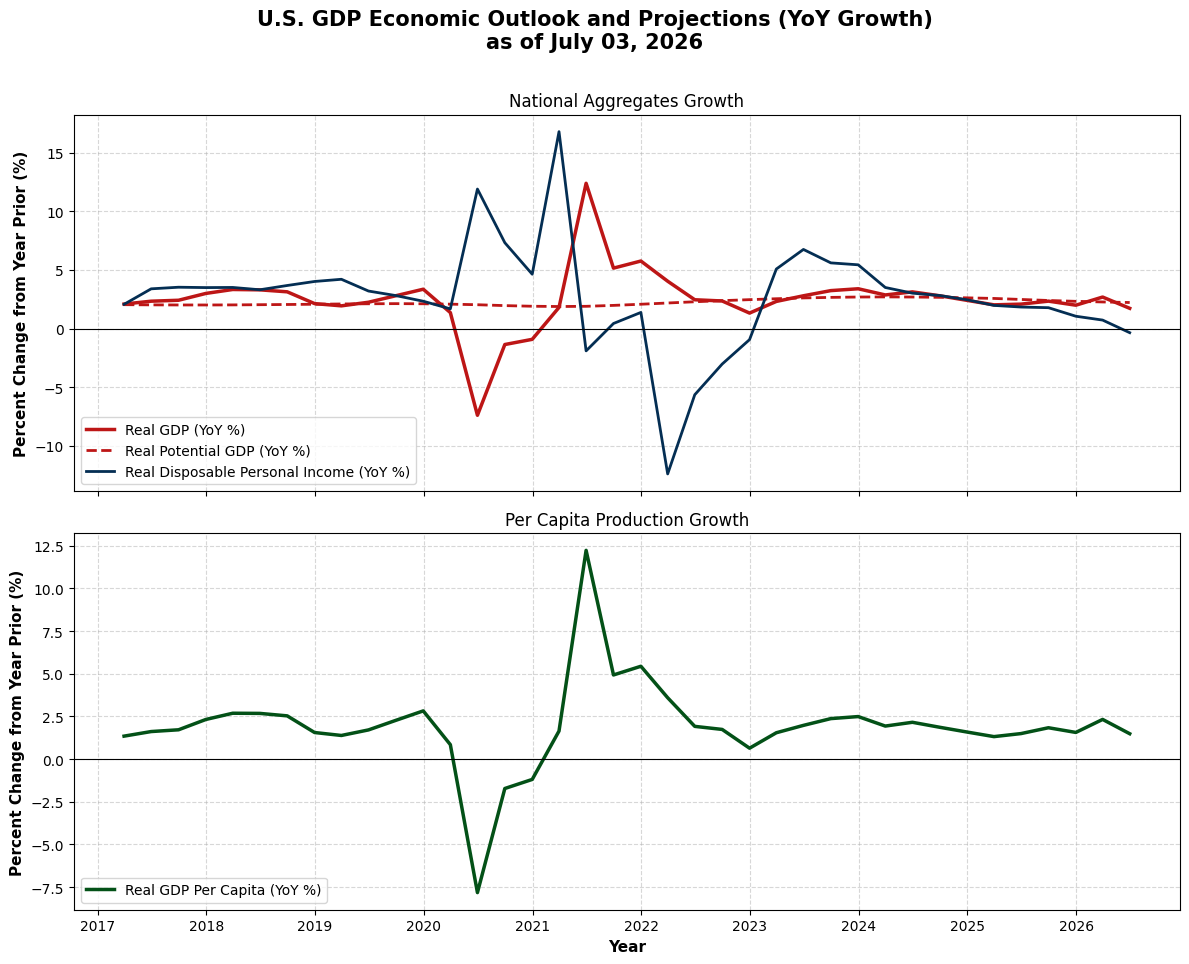

In [16]:
start = datetime(2016, 1, 1)
plot_start = start + relativedelta(years=1)

macro_series = {
    'GDPC1': 'Real GDP',
    'GDPPOT': 'Real Potential GDP',
    'DSPIC96': 'Real Disposable Personal Income',
    'A939RX0Q048SBEA': 'Real GDP Per Capita'
}

df_raw = web.DataReader(list(macro_series.keys()), 'fred', start, end)
df_raw.rename(columns=macro_series, inplace=True)
df_quarterly = df_raw.resample('QE').mean()

df_rate = pd.DataFrame(index=df_quarterly.index)
df_rate['Real GDP'] = df_quarterly['Real GDP'].pct_change(4) * 100
df_rate['Real Potential GDP'] = df_quarterly['Real Potential GDP'].pct_change(4) * 100
df_rate['Real Disposable Personal Income'] = df_quarterly['Real Disposable Personal Income'].pct_change(4) * 100
df_rate['Real GDP Per Capita'] = df_quarterly['Real GDP Per Capita'].pct_change(4) * 100

df_plot = df_rate.loc[plot_start:end]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(df_plot.index, df_plot['Real GDP'], 
         label='Real GDP (YoY %)', 
         color='#bd1616', 
         linewidth=2.5)

ax1.plot(df_plot.index, df_plot['Real Potential GDP'], 
         label='Real Potential GDP (YoY %)', 
         color='#bd1616', 
         linewidth=2, 
         linestyle='--')

ax1.plot(df_plot.index, df_plot['Real Disposable Personal Income'], 
         label='Real Disposable Personal Income (YoY %)', 
         color='#042E53', 
         linewidth=2)
        
ax1.set_ylabel('Percent Change from Year Prior (%)', fontweight='bold', fontsize=11)
ax1.title.set_text('National Aggregates Growth')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax1.legend(loc='lower left', frameon=True)

ax2.plot(df_plot.index, df_plot['Real GDP Per Capita'], 
         label='Real GDP Per Capita (YoY %)', color='#035117', linewidth=2.5)

ax2.set_xlabel('Year', fontweight='bold', fontsize=11)
ax2.set_ylabel('Percent Change from Year Prior (%)', fontweight='bold', fontsize=11)
ax2.title.set_text('Per Capita Production Growth')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax2.legend(loc='lower left', frameon=True)

y1_text = df_plot[['Real GDP', 'Real Potential GDP', 'Real Disposable Personal Income']].max().max() * 0.8
y2_text = df_plot['Real GDP Per Capita'].max() 

        
plt.suptitle(f'U.S. GDP Economic Outlook and Projections (YoY Growth)\nas of {str_current_date}', 
             fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Conclusions and Observations

### Wages – 25 June 2026

#### Wage growth over the last 6 months was a rocky road to say the least.

In light of inflationary responses to present circumstances, the well-touted wage gains over the last year were effectively wiped out and even reduced beyond their growth.

For Private employers, workers earned **$1,287.28/week** on average, equivalent to *$66,938.56/year*.

For workers in possession of a bachelor's degree or higher, this group earned **$1,763.00/week** on average, equivalent to *$91,676.00/year*.

For all workers 16-years old or older, this group earned **$1,233.00/week** on average, equivalent to *$64,116.00/year*.

**The private employee earnings are performing the best... which shows the underlying issues the most.**

Over the last three, six, and twelve months, private workers saw their wages increase by **0.698%**, **1.432%**, and **3.748%** respectively. 

*However*, as annualized inflation rose to <u>4.2% in the last year</u> — an increase of ***0.8% from just the previous month*** — <u>every dollar of that growth was eliminatated beyond the wages actually paid</u>.

Bachelors degree holders and all workers as a whole saw gains of **0.916%** and **1.481%** in the last 6 months. These same groups saw **1.789%** and **2.324%** gains, respectively, in the previous 12 months.

#### And this doesn't account for taxes, insurance, healthcare, retirement, garnishments, annuities, investments, or anything else. Just wages.

With Real Personal Expenditure Per Capita increasing, which is the dollar figure representing the amount of U.S. dollars spent per person, taken as an average of the country's census population and total consumer expenditure, wages did not keep up.

As immigration continues its rapid changes, total wages are also being affected in a similar manner. 

Expenditure grew by **0.306%** and **1.453%** over the last 6 months and 12 months, respectively.

### Bottom Line, inflation is outpacing wage growth, and the cost of living continues to rise.

*So you shouldn't feel bad about paying $7 for that fish taco. Get the $17 clams and mussels if you want it.* 

You just may have helped another person's dream come true, and enjoyed yourself doing it.

After considering the salmon, I'll have the steak and fries. <u>Hummus and pita is for the table.</u>

___

**Thank you for reading. I'm clearly feeling hungry and eat out maybe once or twice a week since most of my meals are prepared at home.** 

**While we're on the topic, if you're considering buying or selling real estate, I've also released a report on <u>U.S. Housing Market Indicies</u>. For now, rent is due every day, and my dues have been paid.**

___


#### Update Schedule

- ***Gross Domestic Product - Jul 30, 2026***

    1. `GDPC1`: **Real Gross Domestic Product**
    2. `DSPIC96`: **Real Disposable Personal Income**
    3. `A939RX0Q048SBEA`: **Real GDP Per Capita** 

- ***Median Weekly Earnings - Jul 21, 2026***

    4. `LES1252881500Q`: **Employed Full time: Median Weekly Earnings: 16 Years and Older**
    5. `LEU0252918500Q`: **Employed Full time: Median Weekly Earnings: Bachelor's Degree and Higher**

- ***Average Weekly Earnings - Aug 7, 2026***

    6. `CES0500000011`: **Average Weekly Earnings of All Employees, Total Private**

#### Data Changelog / Notes

1. **U.S. GDP Economic Outlook and Projections (YoY Growth)**
    - `All Workers (YoY %Change)`
        - *Recorded as quarterly*
    - `College Graduates (YoY %Change)`
        - *Recorded as quarterly*
    - `Total Private Employees (YoY %Change)`
        - *Recorded as monthly*

2. **Real Potential Gross Domestic Product**
    - `Next Update Unknown`
        - FRED has not released update regarding this metric.

#### ***Review and analysis publishing on Friday, July 24, 2026,at 1:30 P.M., Pacific Time.***